In [1]:
!pip install yfinance pandas numpy matplotlib seaborn plotly ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=a8547c86f4d8cbbc8ab7c9fb5a300e309d861f7433c2493430964f6e1b9013f5
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ticker = "AAPL"

df = yf.download(ticker, start="2020-01-01", end="2026-01-01")

df.head()

/tmp/ipykernel_3119/1034692954.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [5]:
df.to_csv("stock_data.csv", index=False)

In [6]:
from google.colab import files
files.download("stock_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
df = df.dropna()
df = df.reset_index()
df.head()

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL
0,0,2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
1,1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2,2,2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200
3,3,2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
4,4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [8]:
df["Daily Return"] = df["Close"].pct_change()
df.head()

Price,index,Date,Close,High,Low,Open,Volume,Daily Return
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,0,2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400,NaN
1,1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,-0.009722
2,2,2020-01-06,72.201424,72.239958,70.503561,70.754028,118387200,0.007968
3,3,2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,-0.004703
4,4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,0.016086


In [9]:
df["Daily Return"] = df["Close"].pct_change()

In [10]:
df.to_csv("stock_phase3_daily_returns.csv", index=False)

In [11]:
from google.colab import files
files.download("stock_phase3_daily_returns.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
df["SMA20"] = df["Close"].rolling(window=20).mean()
df["SMA50"] = df["Close"].rolling(window=50).mean()

In [13]:
df["Volatility"] = df["Daily Return"].rolling(window=20).std()

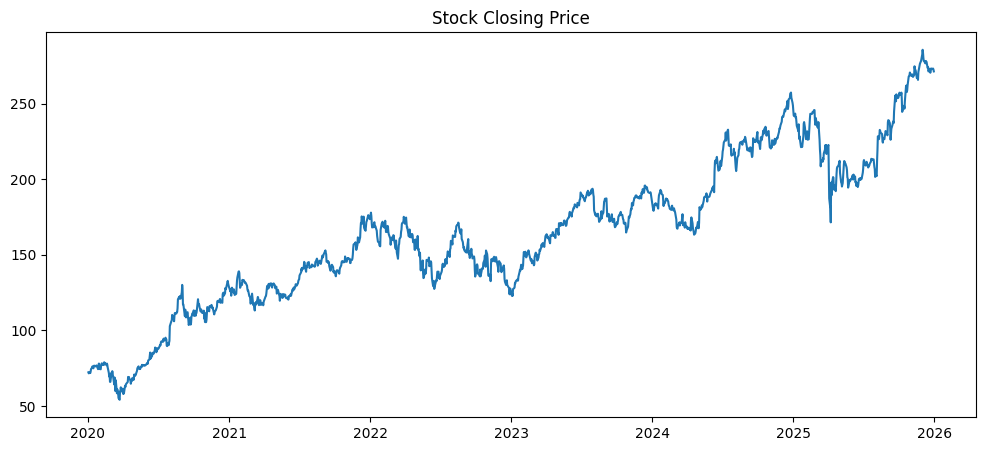

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"])
plt.title("Stock Closing Price")
plt.show()

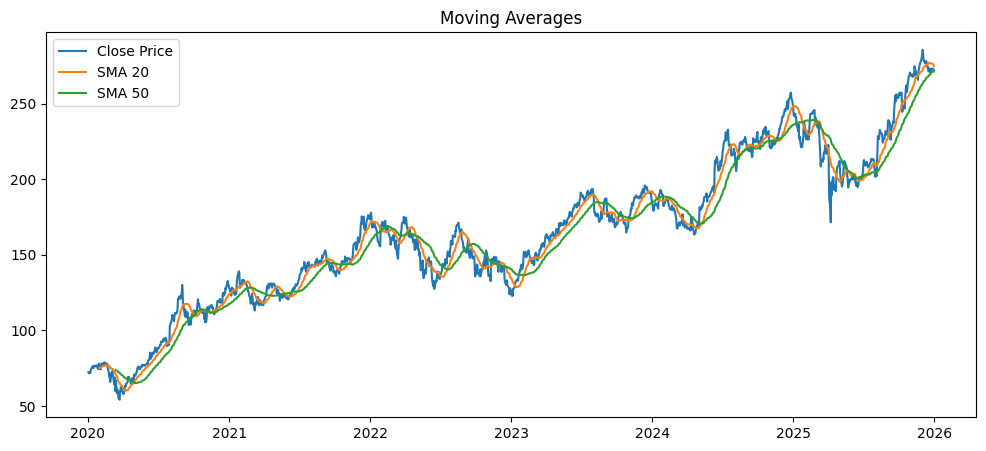

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA20"], label="SMA 20")
plt.plot(df["Date"], df["SMA50"], label="SMA 50")
plt.legend()
plt.title("Moving Averages")
plt.show()

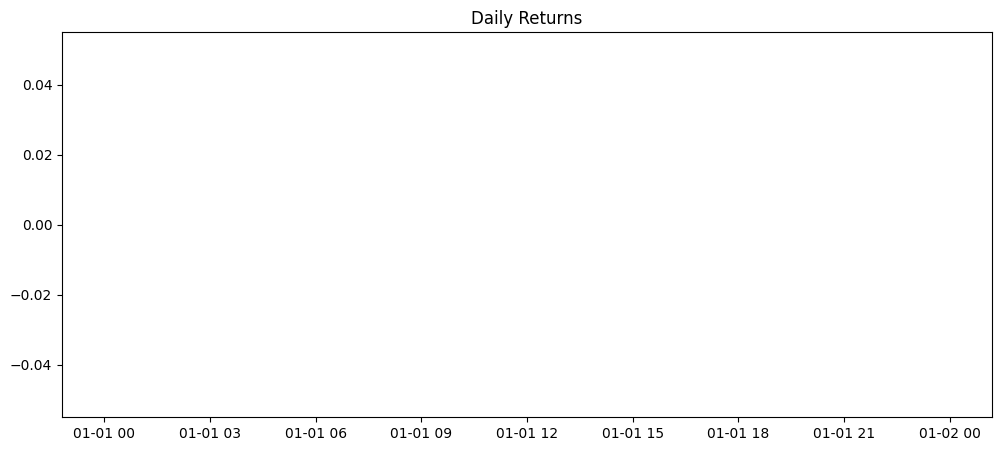

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Daily Return"])
plt.title("Daily Returns")
plt.show()

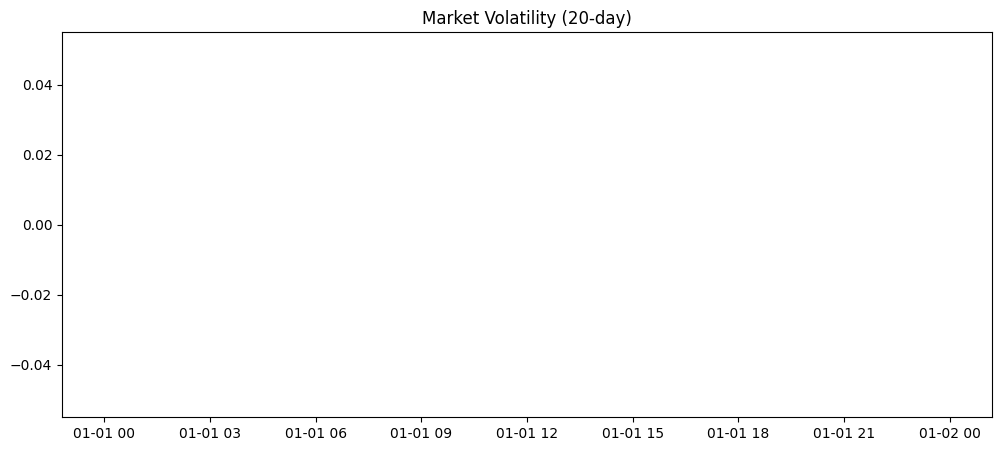

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Volatility"])
plt.title("Market Volatility (20-day)")
plt.show()

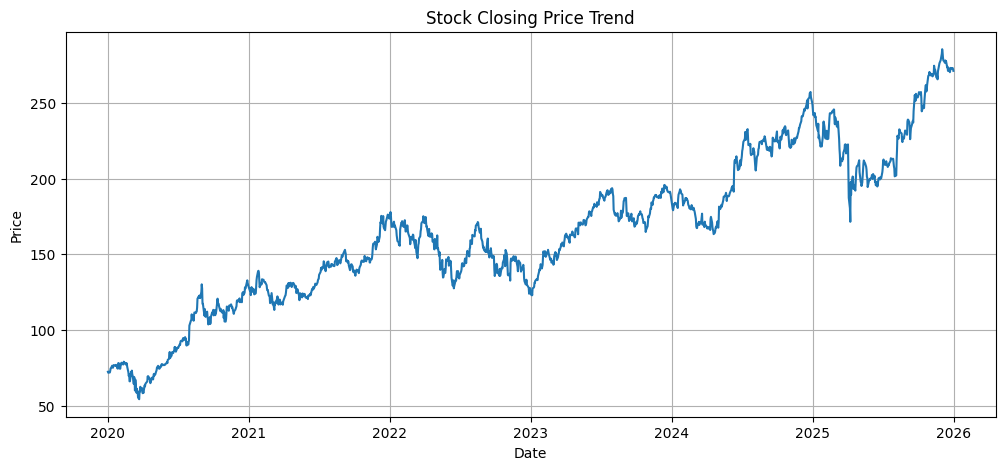

In [18]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"])
plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

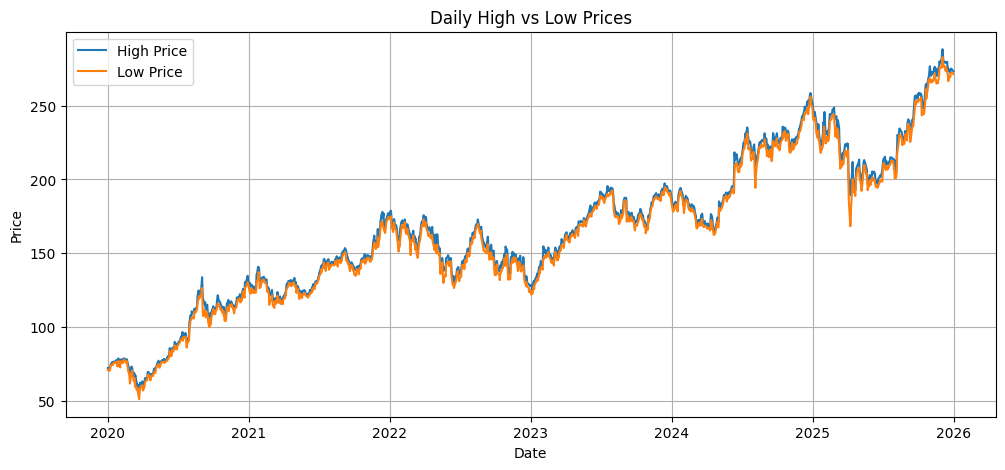

In [19]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["High"], label="High Price")
plt.plot(df["Date"], df["Low"], label="Low Price")

plt.title("Daily High vs Low Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [20]:
df.to_csv("final_stock_analysis.csv", index=False)

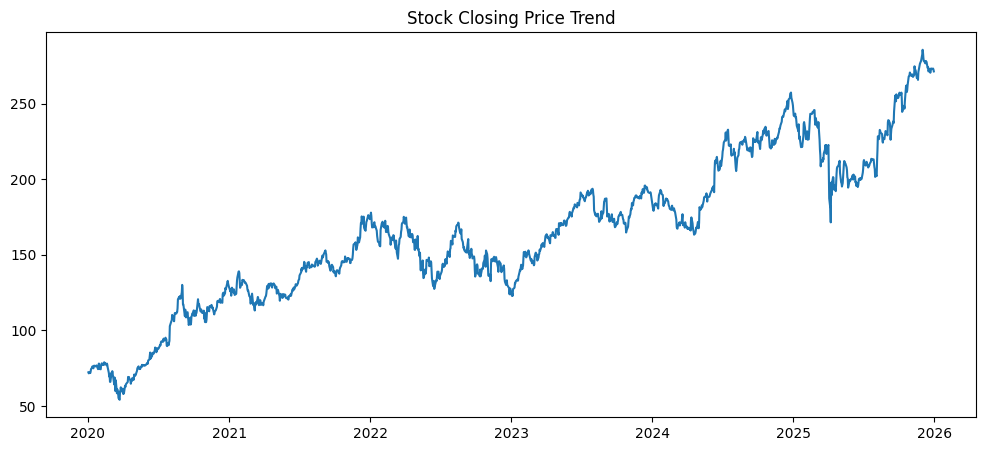

In [21]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"])
plt.title("Stock Closing Price Trend")
plt.savefig("graph_close_price.png")
plt.show()

In [24]:
from google.colab import files
files.download("Stock_Market_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
from google.colab import files
files.download("Stock_Market_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>